# Notebook 2: ML Baseline — HOG + SVM
**Brain Tumor MRI Classification — PyTorch Version**

Classical ML baseline using scikit-learn (no PyTorch needed here).
This establishes the performance floor that EfficientNet will beat.

## 0. Setup

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from tqdm import tqdm

from skimage.feature import hog
from skimage import exposure

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score
)

TRAIN_DIR = Path('data/Training')
TEST_DIR  = Path('data/Testing')
CLASSES   = ['glioma', 'meningioma', 'notumor', 'pituitary']
IMG_SIZE  = (128, 128)

os.makedirs('results', exist_ok=True)
os.makedirs('models',  exist_ok=True)
np.random.seed(42)
print('Setup complete.')

Setup complete.


## 1. HOG Feature Extraction

In [2]:
def extract_hog_features(img_path):
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    img = cv2.resize(img, IMG_SIZE)
    return hog(img, orientations=9, pixels_per_cell=(8, 8),
               cells_per_block=(2, 2), block_norm='L2-Hys')


def load_dataset(base_dir):
    X, y = [], []
    for cls in CLASSES:
        paths = list((base_dir / cls).glob('*.jpg')) + \
                list((base_dir / cls).glob('*.png'))
        for p in tqdm(paths, desc=f'  {cls}'):
            feats = extract_hog_features(p)
            if feats is not None:
                X.append(feats)
                y.append(cls)
    return np.array(X), np.array(y)


print('Extracting train HOG features...')
X_train, y_train = load_dataset(TRAIN_DIR)
print(f'Train shape: {X_train.shape}')

print('Extracting test HOG features...')
X_test, y_test = load_dataset(TEST_DIR)
print(f'Test shape:  {X_test.shape}')

Extracting train HOG features...


  pituitary: 100%|██████████| 827/827 [00:03<00:00, 231.18it/s]


Train shape: (2870, 8100)
Extracting test HOG features...


  pituitary: 100%|██████████| 74/74 [00:00<00:00, 201.85it/s]

Test shape:  (394, 8100)


## 2. HOG Visualization

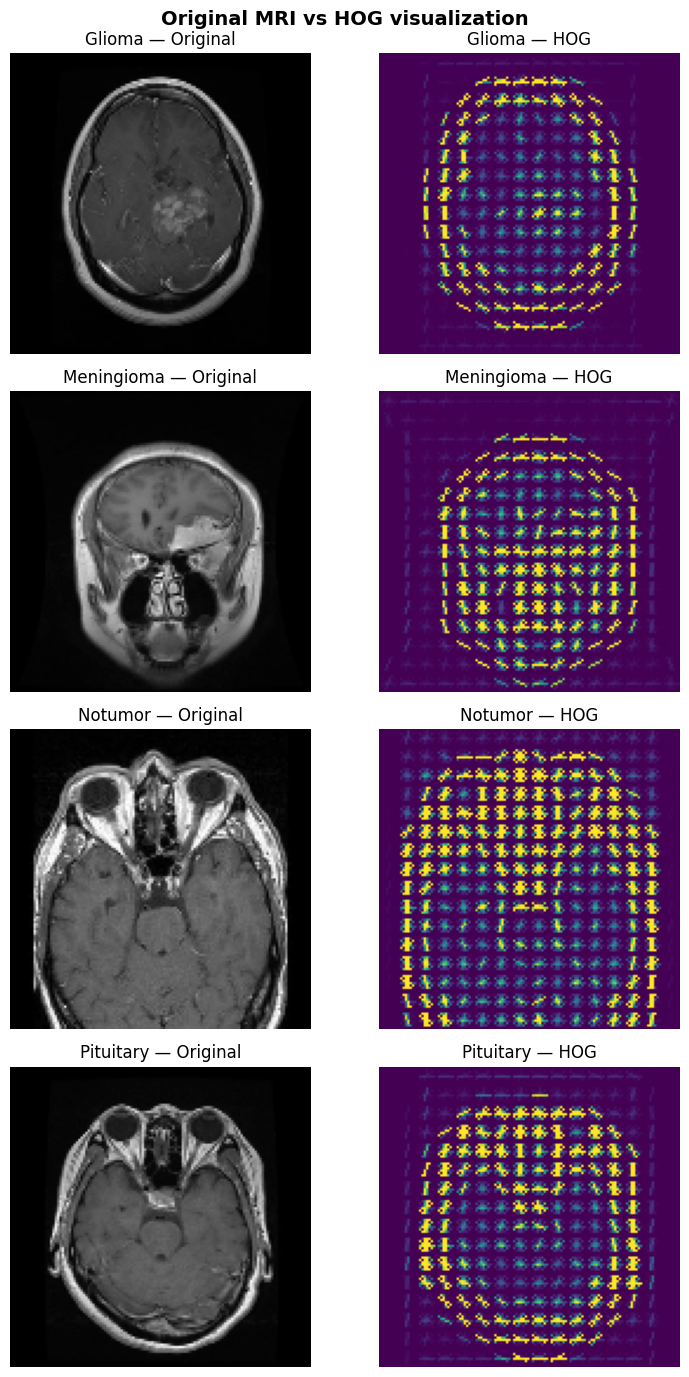

In [3]:
COLORS = ['#4361EE', '#F72585', '#4CC9F0', '#7209B7']
fig, axes = plt.subplots(4, 2, figsize=(8, 14))
fig.suptitle('Original MRI vs HOG visualization', fontsize=14, fontweight='bold')

for row_idx, cls in enumerate(CLASSES):
    img_path = list((TRAIN_DIR / cls).glob('*.jpg'))[0]
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, IMG_SIZE)

    _, hog_img = hog(img, orientations=9, pixels_per_cell=(8, 8),
                     cells_per_block=(2, 2), block_norm='L2-Hys', visualize=True)
    hog_img = exposure.rescale_intensity(hog_img, in_range=(0, 10))

    axes[row_idx][0].imshow(img, cmap='gray')
    axes[row_idx][0].set_title(f'{cls.capitalize()} — Original')
    axes[row_idx][0].axis('off')

    axes[row_idx][1].imshow(hog_img, cmap='viridis')
    axes[row_idx][1].set_title(f'{cls.capitalize()} — HOG')
    axes[row_idx][1].axis('off')

plt.tight_layout()
plt.savefig('results/hog_visualization.png', bbox_inches='tight')
plt.show()

## 3. Scale Features & Encode Labels

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

print('Classes:', le.classes_)
print('Feature vector length:', X_train_scaled.shape[1])

Classes: ['glioma' 'meningioma' 'notumor' 'pituitary']
Feature vector length: 8100


## 4. Train SVM

In [5]:
# Small grid search with stratified 3-fold CV.
# Kept compact so it finishes in a reasonable time on HOG features.
param_grid = {
    'C':      [1, 10, 100],
    'gamma':  ['scale', 0.01],
    'kernel': ['rbf'],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    refit=True,
)
grid.fit(X_train_scaled, y_train_enc)

print(f'Best params : {grid.best_params_}')
print(f'Best CV f1  : {grid.best_score_:.4f}')

svm = grid.best_estimator_

train_acc = accuracy_score(y_train_enc, svm.predict(X_train_scaled))
test_acc  = accuracy_score(y_test_enc,  svm.predict(X_test_scaled))
print(f'Train accuracy : {train_acc:.4f}')
print(f'Test accuracy  : {test_acc:.4f}')

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best params : {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV f1  : 0.9139
Train accuracy : 1.0000
Test accuracy  : 0.7716


## 5. Full Evaluation

In [6]:
y_pred       = svm.predict(X_test_scaled)
y_pred_proba = svm.predict_proba(X_test_scaled)

print('='*55)
print('SVM CLASSIFICATION REPORT')
print('='*55)
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

auc = roc_auc_score(y_test_enc, y_pred_proba, multi_class='ovr', average='macro')
print(f'Macro ROC-AUC: {auc:.4f}')

SVM CLASSIFICATION REPORT
              precision    recall  f1-score   support

      glioma       1.00      0.18      0.31       100
  meningioma       0.74      0.98      0.84       115
     notumor       0.68      1.00      0.81       105
   pituitary       0.99      0.92      0.95        74

    accuracy                           0.77       394
   macro avg       0.85      0.77      0.73       394
weighted avg       0.84      0.77      0.72       394

Macro ROC-AUC: 0.9456


## 6. Confusion Matrix

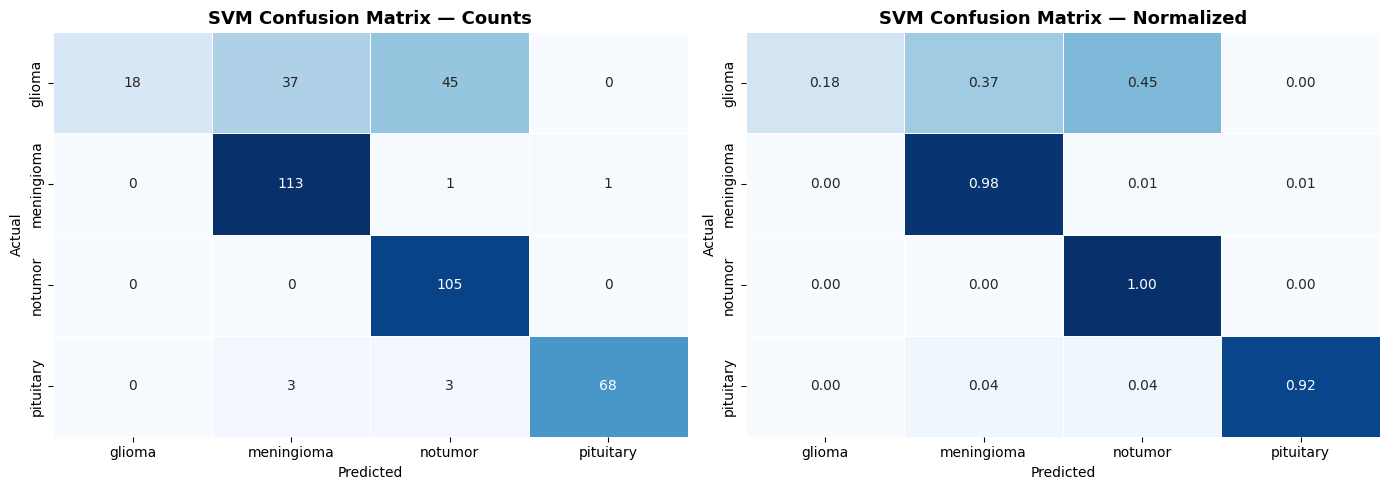

In [7]:
cm      = confusion_matrix(y_test_enc, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, data, title, fmt in zip(
        axes, [cm, cm_norm],
        ['Counts', 'Normalized'], ['d', '.2f']):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_,
                linewidths=0.5, ax=ax, cbar=False)
    ax.set_title(f'SVM Confusion Matrix — {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('results/svm_confusion_matrix.png', bbox_inches='tight')
plt.show()

## 7. Save Model

In [8]:
joblib.dump(svm,    'models/svm_model.pkl')
joblib.dump(scaler, 'models/svm_scaler.pkl')
joblib.dump(le,     'models/label_encoder.pkl')
print('Saved to models/')

Saved to models/


## 8. Export baseline metrics for the comparison dashboard

Persist the SVM baseline's headline metrics to `results/baseline_results.json` so notebook 06 can pull the Classical-ML row into the cross-model comparison without re-running this notebook.

In [9]:
import json, os
from sklearn.metrics import f1_score

os.makedirs("results", exist_ok=True)

# Headline metrics for the one classical-ML baseline (HOG + SVM).
baseline = [{
    "tag": "svm_hog",
    "accuracy": float(accuracy_score(y_test_enc, y_pred)),
    "macro_f1": float(f1_score(y_test_enc, y_pred, average="macro")),
    "weighted_f1": float(f1_score(y_test_enc, y_pred, average="weighted")),
    "macro_roc_auc": float(auc),
    # Classical model: ECE/temperature scaling not applicable; param
    # count is the flattened HOG dimensionality, not a fair "M" figure.
    "ece": None,
    "params_m": None,
}]

with open("results/baseline_results.json", "w") as fh:
    json.dump(baseline, fh, indent=2)
print("Saved results/baseline_results.json")
print(json.dumps(baseline, indent=2))

Saved results/baseline_results.json
[
  {
    "tag": "svm_hog",
    "accuracy": 0.7715736040609137,
    "macro_f1": 0.7275570224280066,
    "weighted_f1": 0.7182711777394091,
    "macro_roc_auc": 0.9456478916512152,
    "ece": null,
    "params_m": null
  }
]
